In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
clean_data = pd.read_parquet("../cleaned_data/clean_yellow_tripdata_2026-01.parquet")

In [6]:
df = clean_data.copy()

In [7]:
df.shape

(1773708, 39)

In [8]:
df.memory_usage(deep=True).sum()/(1024*1024)

np.float64(526.1815071105957)

# mta_tax_amount

In [9]:
df['mta_tax_amount'].describe()

count    1.773708e+06
mean     4.934222e-01
std      5.697024e-02
min      0.000000e+00
25%      5.000000e-01
50%      5.000000e-01
75%      5.000000e-01
max      5.000000e-01
Name: mta_tax_amount, dtype: float64

In [10]:
df['mta_tax_amount'].quantile([0.9,0.99,0.995,0.999,0.9995,0.9999])

0.9000    0.5
0.9900    0.5
0.9950    0.5
0.9990    0.5
0.9995    0.5
0.9999    0.5
Name: mta_tax_amount, dtype: float64

In [11]:
df[(df['mta_tax_amount']>0.5)]

,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,trip_distance,fare_type_id,store_and_fwd_flag,pickup_location_id,dropoff_location_id,payment_type,...,distance_ratio,pickup_borough,pickup_zone,pickup_service_type,dropoff_borough,dropoff_zone,dropoff_service_type,fare_type_zone_mismatch,fare_per_distance,non_cc_positive_tip


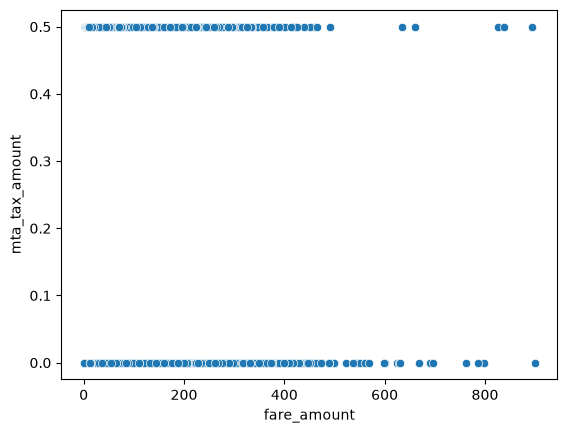

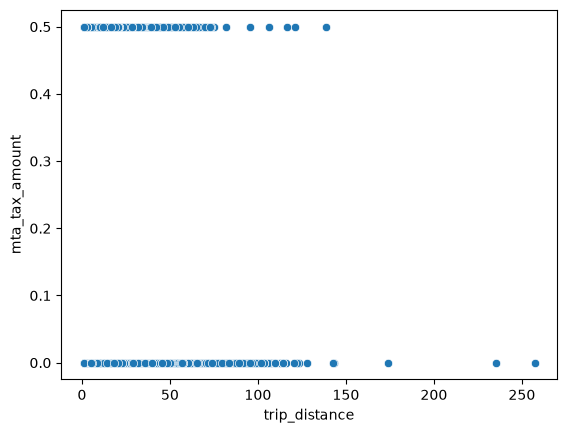

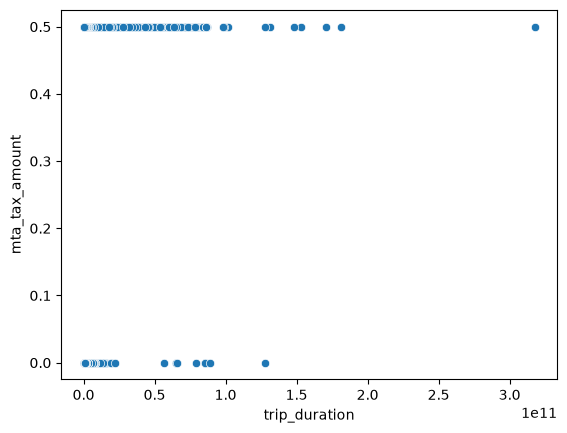

In [12]:
sns.scatterplot(
    x = df['fare_amount'],
    y = df['mta_tax_amount']
)
plt.show()
sns.scatterplot(
    x = df['trip_distance'],
    y = df['mta_tax_amount']
)
plt.show()
sns.scatterplot(
    x = df['trip_duration'],
    y = df['mta_tax_amount']
)
plt.show()

# remove mta_tax_amount > 1.0

In [13]:
df = df[df['mta_tax_amount'] < 1.0]

In [14]:
df['mta_tax_amount'] = df['mta_tax_amount'].astype('float32')

In [15]:
df = df.reset_index(drop=True)

In [16]:
df.memory_usage(deep=True).sum()/(1024*1024)

np.float64(526.1815071105957)

# tip_amount

In [17]:
df['tip_amount'].describe()

count    1.773708e+06
mean     4.086123e+00
std      4.317233e+00
min      0.000000e+00
25%      1.180000e+00
50%      3.370000e+00
75%      5.000000e+00
max      9.999000e+01
Name: tip_amount, dtype: float64

In [18]:
df['tip_amount'].quantile([0.9,0.99,0.995,0.999,0.9999,0.999995])

0.900000     9.110000
0.990000    19.019300
0.995000    21.500000
0.999000    31.872930
0.999900    67.256294
0.999995    99.000000
Name: tip_amount, dtype: float64

In [19]:
df.groupby('payment_type')['tip_amount'].mean()

payment_type
1    4.655132
2    0.000476
3    0.000000
4    0.000567
Name: tip_amount, dtype: float32

In [20]:
df[(df['payment_type'] == 2) & (df['tip_amount']>0)]

,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,trip_distance,fare_type_id,store_and_fwd_flag,pickup_location_id,dropoff_location_id,payment_type,...,distance_ratio,pickup_borough,pickup_zone,pickup_service_type,dropoff_borough,dropoff_zone,dropoff_service_type,fare_type_zone_mismatch,fare_per_distance,non_cc_positive_tip
25223,2,2026-01-01 14:20:57,2026-01-01 14:34:53,1,1.990000,1,False,161,236,2,...,1.061770,Manhattan,Midtown Center,Yellow Zone,Manhattan,Upper East Side North,Yellow Zone,None,7.487437,True
158480,2,2026-01-04 06:08:21,2026-01-04 06:14:38,1,1.700000,1,False,263,238,2,...,1.168006,Manhattan,Yorkville West,Yellow Zone,Manhattan,Upper West Side North,Yellow Zone,None,5.882353,True
175075,2,2026-01-04 14:59:44,2026-01-04 15:09:27,1,1.650000,1,False,161,43,2,...,0.924028,Manhattan,Midtown Center,Yellow Zone,Manhattan,Central Park,Yellow Zone,None,6.909091,True
324522,2,2026-01-07 09:11:43,2026-01-07 09:29:25,3,2.110000,1,False,230,234,2,...,1.518852,Manhattan,Times Sq/Theatre District,Yellow Zone,Manhattan,Union Sq,Yellow Zone,None,7.725119,True
562737,2,2026-01-10 20:48:10,2026-01-10 20:55:03,1,1.700000,1,False,142,151,2,...,0.943968,Manhattan,Lincoln Square East,Yellow Zone,Manhattan,Manhattan Valley,Yellow Zone,None,5.882353,True
719752,2,2026-01-13 14:04:02,2026-01-13 14:15:46,1,1.420000,1,False,142,140,2,...,0.936088,Manhattan,Lincoln Square East,Yellow Zone,Manhattan,Lenox Hill East,Yellow Zone,None,8.521127,True
815425,2,2026-01-14 20:46:03,2026-01-14 20:53:58,1,1.050000,1,False,237,141,2,...,3.141265,Manhattan,Upper East Side South,Yellow Zone,Manhattan,Lenox Hill West,Yellow Zone,None,8.857143,True
913001,2,2026-01-16 08:24:07,2026-01-16 08:53:13,1,5.530000,1,False,68,75,2,...,1.349153,Manhattan,East Chelsea,Yellow Zone,Manhattan,East Harlem South,Boro Zone,None,5.732368,True
1000942,2,2026-01-17 15:18:19,2026-01-17 15:36:04,1,2.520000,1,False,186,142,2,...,1.361715,Manhattan,Penn Station/Madison Sq West,Yellow Zone,Manhattan,Lincoln Square East,Yellow Zone,None,7.023809,True
1011511,2,2026-01-17 18:14:44,2026-01-17 18:36:06,2,2.670000,1,False,161,211,2,...,0.995295,Manhattan,Midtown Center,Yellow Zone,Manhattan,SoHo,Yellow Zone,None,7.153558,True


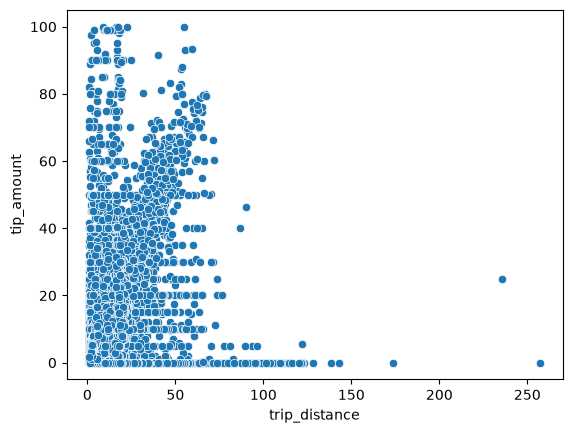

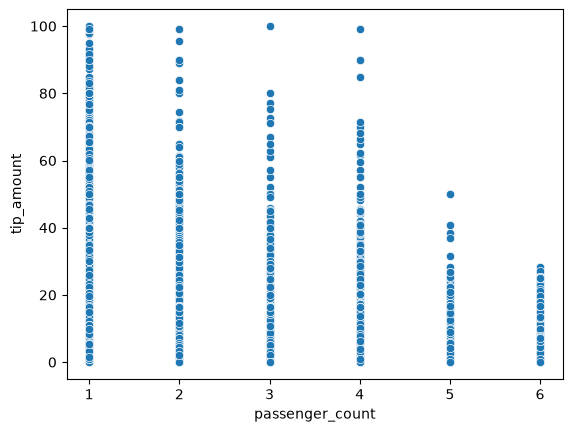

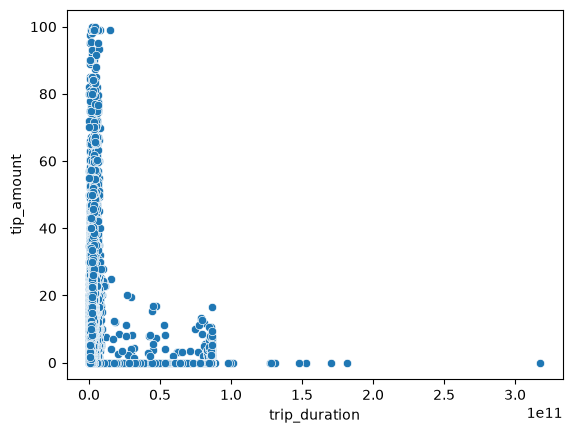

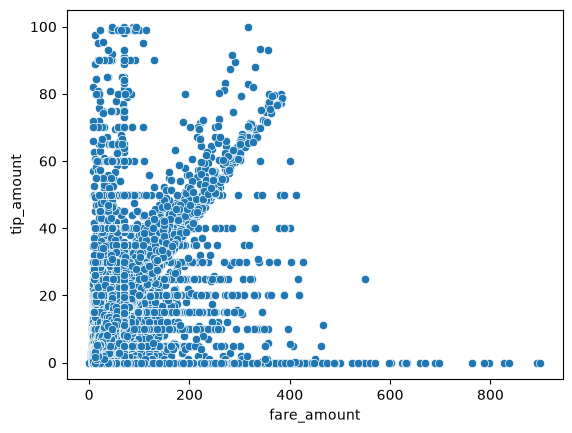

In [21]:
# sns.pairplot(df[['tip_amount' , 'trip_distance', 'passenger_count', 'trip_duration', 'fare_amount', 'payment_type']])
sns.scatterplot(
    x = df['trip_distance'],
    y = df['tip_amount']
)
plt.show()
sns.scatterplot(
    x = df['passenger_count'],
    y = df['tip_amount']
)
plt.show()
sns.scatterplot(
    x = df['trip_duration'],
    y = df['tip_amount']
)
plt.show()
sns.scatterplot(
    x = df['fare_amount'],
    y = df['tip_amount']
)
plt.show()

# remove outliers in tip_amount

In [22]:
(df['tip_amount'] > 80).sum()

np.int64(92)

# remove those tip_amount > 100

In [23]:
df = df[df['tip_amount'] < 100]

In [24]:
df[df["payment_type"] != 1]["tip_amount"].describe()


count    216827.000000
mean          0.000472
std           0.065576
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          17.790001
Name: tip_amount, dtype: float64

# non consistence tip_amount

In [25]:
positive_non_cc = (
    (df["payment_type"] != 1) &
    (df["tip_amount"] > 0)
).sum()

total_non_cc = (df["payment_type"] != 1).sum()
print(positive_non_cc, total_non_cc)
positive_non_cc / total_non_cc * 100


18 216827


np.float64(0.008301549161312935)

In [26]:
df[(
    (df["payment_type"] != 1) &
    (df["tip_amount"] > 0)
)]['tip_amount'].quantile([0.5,0.9,0.99,0.995,0.999,0.9999,0.999995])

0.500000     4.490000
0.900000    10.395000
0.990000    17.764501
0.995000    17.777251
0.999000    17.787451
0.999900    17.789746
0.999995    17.789988
Name: tip_amount, dtype: float64

# mark inconsistence tip amounts

In [27]:
df["non_cc_positive_tip"] = (
    (df["payment_type"] != 1) &
    (df["tip_amount"] > 0)
)

In [28]:
df[['tip_amount', 'non_cc_positive_tip']].info()

<class 'pandas.DataFrame'>
RangeIndex: 1773708 entries, 0 to 1773707
Data columns (total 2 columns):
 #   Column               Dtype  
---  ------               -----  
 0   tip_amount           float32
 1   non_cc_positive_tip  bool   
dtypes: bool(1), float32(1)
memory usage: 8.5 MB


In [29]:
df['tip_amount'] = df['tip_amount'].astype('float32')
df['non_cc_positive_tip'] = df['non_cc_positive_tip'].astype('boolean')

# tolls_amount

In [30]:
print(df['tolls_amount'].describe())
print(df['tolls_amount'].quantile([0.9,0.990,0.999,0.9995,0.9999]))

count    1.773708e+06
mean     7.843545e-01
std      2.579916e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.222200e+02
Name: tolls_amount, dtype: float64
0.9000     0.000000
0.9900     7.460000
0.9990    23.790001
0.9995    26.690001
0.9999    37.169998
Name: tolls_amount, dtype: float64


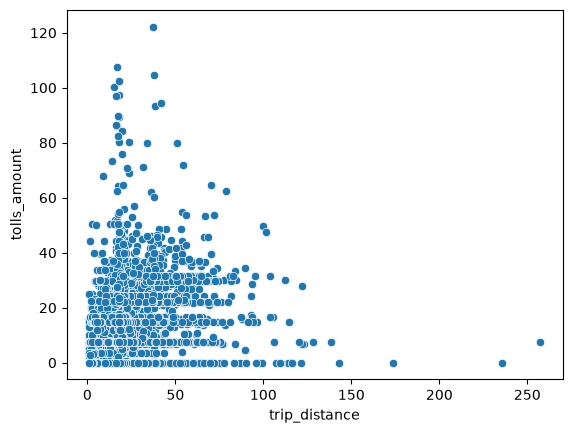

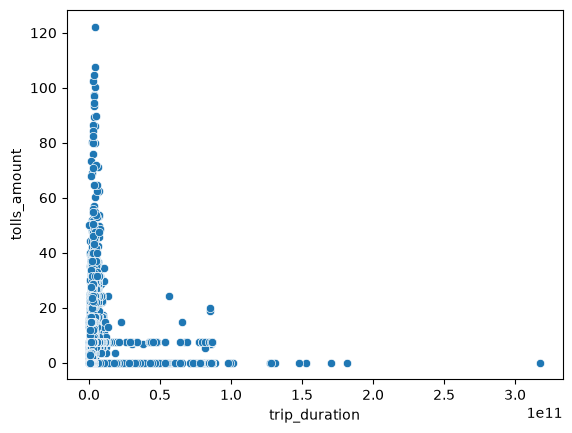

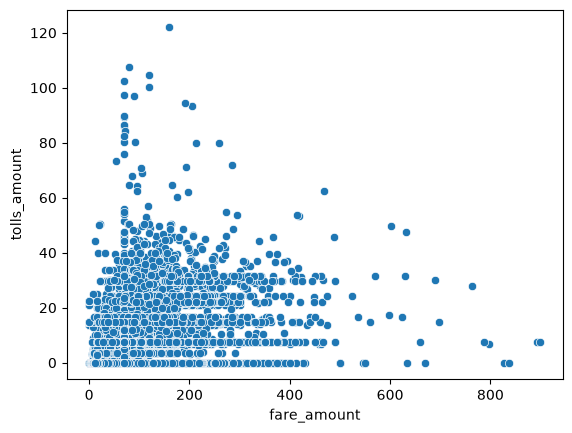

In [31]:
sns.scatterplot(
    y = df['tolls_amount'],
    x = df['trip_distance']
)
plt.show()
sns.scatterplot(
    y = df['tolls_amount'],
    x = df['trip_duration']
)
plt.show()
sns.scatterplot(
    y = df['tolls_amount'],
    x = df['fare_amount']
)
plt.show()


In [32]:
pd.set_option('display.max_rows', None)

print(
    df.groupby(['pickup_borough', 'pickup_zone'])['tolls_amount']
      .mean()
      .sort_values(ascending=False)
      .head(30)
)

print("\n\n")

print(
    df.groupby(['dropoff_borough', 'dropoff_zone'])['tolls_amount']
      .mean()
      .sort_values(ascending=False)
      .head(30)
)


pickup_borough  pickup_zone                     
Staten Island   Arrochar/Fort Wadsworth             19.271364
                South Beach/Dongan Hills            14.919999
EWR             Newark Airport                      12.194000
Staten Island   New Dorp/Midland Beach              11.913333
                Great Kills                          7.460000
                Bloomfield/Emerson Hill              6.024000
                Stapleton                            5.760000
Queens          Jamaica Bay                          4.973333
Staten Island   Heartland Village/Todt Hill          4.973333
Queens          College Point                        4.892421
                LaGuardia Airport                    4.811100
                East Elmhurst                        4.673532
Manhattan       Randalls Island                      4.277500
Queens          Bay Terrace/Fort Totten              3.934118
Bronx           Country Club                         3.841333
Queens          White

In [33]:
df['tolls_amount'] = df['tolls_amount'].astype('float32')

# improvement_surcharge_amount

In [34]:
df['improvement_surcharge_amount'].describe()

count    1.773708e+06
mean     9.444001e-01
std      2.291475e-01
min      0.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
Name: improvement_surcharge_amount, dtype: float64

In [35]:
df['improvement_surcharge_amount'] = df['improvement_surcharge_amount'].astype('float32')

# congestion_surcharge_amount

In [36]:
df['congestion_surcharge_amount'].describe()

count    1.773708e+06
mean     2.166432e+00
std      8.500900e-01
min      0.000000e+00
25%      2.500000e+00
50%      2.500000e+00
75%      2.500000e+00
max      2.500000e+00
Name: congestion_surcharge_amount, dtype: float64

In [37]:
df['congestion_surcharge_amount'] = df['congestion_surcharge_amount'].astype('float32')

# airport_fee_amount

In [38]:
df['airport_fee_amount'].describe()

count    1.773708e+06
mean     2.104381e-01
std      5.691948e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.750000e+00
Name: airport_fee_amount, dtype: float64

In [39]:
is_airport = (
    (df['pickup_zone']=='LaGuardia') |  (df['dropoff_zone']=='LaGuardia')|
    (df['pickup_zone']=='JFK Airport') | (df['dropoff_zone']=='JFK Airport')|
    (df['pickup_zone']=='Newark Airport') | (df['dropoff_zone']=='Newark Airport') |
    (df['pickup_zone'].str.contains('airport')) | (df['dropoff_zone'].str.contains('airport'))
)

((df['airport_fee_amount'] > 0) & (~is_airport)).sum()

np.int64(83081)

In [40]:
is_airport.sum()

np.int64(152559)

In [41]:
(83081/df.shape[0])*100

4.684029163763145

In [42]:
print(
    df[~is_airport].groupby(
    ['pickup_borough', 'pickup_zone']
)['airport_fee_amount'].mean().sort_values(ascending=False).head(20)
)

print(
    df[~is_airport].groupby(
    ['dropoff_borough', 'dropoff_zone']
)['airport_fee_amount'].mean().sort_values(ascending=False).head(20)
)

pickup_borough  pickup_zone            
Queens          LaGuardia Airport          1.747466
                East Elmhurst              1.437858
Bronx           Country Club               0.058333
Unknown         Unknown                    0.049369
Queens          Jackson Heights            0.046667
                Bay Terrace/Fort Totten    0.025735
                College Point              0.018421
                Whitestone                 0.016667
                Bellerose                  0.014463
                Baisley Park               0.011351
                Elmhurst/Maspeth           0.009259
                Maspeth                    0.008495
Bronx           Allerton/Pelham Gardens    0.006944
Queens          Ridgewood                  0.006119
Unknown         Outside of NYC             0.006076
Bronx           Crotona Park East          0.005663
Brooklyn        Bensonhurst West           0.004237
Queens          Corona                     0.004070
                Elmhurst

In [43]:
df['airport_fee_amount'] = df['airport_fee_amount'].astype('float32')

# cbd_congestion_fee_amount

In [44]:
df['cbd_congestion_fee_amount'].describe()

count    1.773708e+06
mean     5.365011e-01
std      3.384412e-01
min      0.000000e+00
25%      0.000000e+00
50%      7.500000e-01
75%      7.500000e-01
max      7.500000e-01
Name: cbd_congestion_fee_amount, dtype: float64

In [45]:
df['cbd_congestion_fee_amount'] = df['cbd_congestion_fee_amount'].astype('float32')

In [46]:
df = df.reset_index(drop=True)

# total_amount

In [47]:
print(df['total_amount'].describe())
df['total_amount'].quantile([0.9,0.99,0.995,0.999,0.9995,0.9999])

count    1.773708e+06
mean     3.341894e+01
std      2.371296e+01
min      1.100000e+00
25%      1.965000e+01
50%      2.478000e+01
75%      3.618000e+01
max      9.117100e+02
Name: total_amount, dtype: float64


0.9000     67.26000
0.9900    106.61000
0.9950    122.64000
0.9990    197.81586
0.9995    246.49395
0.9999    379.16618
Name: total_amount, dtype: float64

In [48]:
expected_total = (df['fare_amount']+df['extra_amount']+df['mta_tax_amount']+
                        df['tolls_amount']+df['improvement_surcharge_amount']+ df['tip_amount'] +
                        df['congestion_surcharge_amount']+df['airport_fee_amount']+ df['cbd_congestion_fee_amount'])

extra_amount = (df['total_amount'] - expected_total)

In [49]:
extra_amount.shape

(1773708,)

In [50]:
extra_amount.describe()

count    1.773708e+06
mean    -5.091141e-01
std      1.187513e+00
min     -5.000009e+00
25%     -1.220703e-06
50%     -7.629394e-08
75%      3.814697e-07
max      2.500012e+00
dtype: float64

In [51]:
extra_amount.quantile([0.9,0.99,0.995,0.999,0.9995,0.9999])

0.9000    9.155273e-07
0.9900    3.662109e-06
0.9950    5.493164e-06
0.9990    2.499999e+00
0.9995    2.500000e+00
0.9999    2.500002e+00
dtype: float64

In [52]:
df[(extra_amount > 2) | (extra_amount<-1)].shape

(289888, 39)

In [53]:
df['extra_total_amount'] = extra_amount

In [54]:
print(df[(extra_amount<-1)].groupby(['payment_type', 'fare_type_id'])['extra_total_amount'].mean().sort_values(ascending=True).head(30))
print(df[(extra_amount> 2)].groupby(['payment_type', 'fare_type_id'])['extra_total_amount'].mean().sort_values(ascending=False).head(30))

payment_type  fare_type_id
4             2              -4.316176
3             2              -4.211538
1             2              -4.162180
2             2              -4.060733
1             1              -3.134507
4             1              -3.091972
3             1              -3.055874
2             1              -3.028633
3             5              -2.200001
1             5              -2.150943
2             5              -2.075000
1             3              -2.017857
4             5              -1.937500
              4              -1.916669
1             4              -1.857430
2             3              -1.857142
              4              -1.813462
4             3              -1.750010
3             3              -1.749999
              4              -1.749999
Name: extra_total_amount, dtype: float64
payment_type  fare_type_id
2             3               2.500003
3             4               2.500001
1             2               2.500001
4       

In [55]:
print('negative extra')
print(df[(extra_amount<-1)].groupby(['pickup_borough', 'pickup_zone'])['extra_total_amount'].mean().sort_values(ascending=True).head(30))
print(df[(extra_amount<-1)].groupby(['dropoff_borough', 'dropoff_zone'])['extra_total_amount'].mean().sort_values(ascending=True).head(30))

print('possitive extra\n')
print(df[(extra_amount> 2)].groupby(['pickup_borough', 'pickup_zone'])['extra_total_amount'].mean().sort_values(ascending=False).head(30))
print(df[(extra_amount> 2)].groupby(['dropoff_borough', 'dropoff_zone'])['extra_total_amount'].mean().sort_values(ascending=False).head(30))

negative extra
pickup_borough  pickup_zone                  
Queens          LaGuardia Airport               -3.775906
                East Elmhurst                   -3.742708
Brooklyn        Sheepshead Bay                  -3.250003
Queens          Maspeth                         -3.250003
Unknown         Outside of NYC                  -3.250002
Brooklyn        Gowanus                         -3.250002
                Prospect Heights                -3.250001
                Bushwick North                  -3.250001
                Bedford                         -3.250001
Queens          Elmhurst                        -3.250001
Manhattan       Roosevelt Island                -3.250001
Brooklyn        East Williamsburg               -3.250000
                Carroll Gardens                 -3.250000
                Brooklyn Heights                -3.250000
                Williamsburg (North Side)       -3.250000
                Prospect Park                   -3.250000
           

In [56]:
df['extra_total_amount'] = df['extra_total_amount'].astype('float32')

In [58]:
pd.set_option('display.max_rows', None)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1773708 entries, 0 to 1773707
Data columns (total 40 columns):
 #   Column                        Dtype          
---  ------                        -----          
 0   vendor_id                     int8           
 1   pickup_datetime               datetime64[us] 
 2   dropoff_datetime              datetime64[us] 
 3   passenger_count               int8           
 4   trip_distance                 float32        
 5   fare_type_id                  int8           
 6   store_and_fwd_flag            boolean        
 7   pickup_location_id            int16          
 8   dropoff_location_id           int16          
 9   payment_type                  int8           
 10  fare_amount                   float32        
 11  extra_amount                  float32        
 12  mta_tax_amount                float32        
 13  tip_amount                    float32        
 14  tolls_amount                  float32        
 15  improvement_surcharge_amou

In [59]:
df = df.reset_index(drop=True)

# save back to clean data

In [61]:
df.to_parquet('../cleaned_data/clean_yellow_tripdata_2026-01.parquet', index=False)

# store to pg